In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression

In [2]:
#Load breast cancer data.
cancer = load_breast_cancer()

#Feature matrix and target vector.
X = cancer.data
y = cancer.target

print("\nFeature columns: ", cancer.feature_names)
print("\nTarget variables: ", cancer.target_names)
print("\nFeature shape: ", X.shape)
print("\nSample shape: ", y.shape)



Feature columns:  ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target variables:  ['malignant' 'benign']

Feature shape:  (569, 30)

Sample shape:  (569,)


In [3]:
#Creating the data frame.
df = pd.DataFrame(X, columns=cancer.feature_names)
df["target"] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
#Print data types
print("\nData Types: \n", df.dtypes)


Data Types: 
 mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst

In [5]:
#Counting the missing values in each feature.
print("\nMissing values in each feature: ", df.isnull().sum())


Missing values in each feature:  mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [6]:
#Inspecting the target values.
print("\nTarget data type: ", y.dtype)
print("\nTarget values: ", np.unique(y))


Target data type:  int64

Target values:  [0 1]


In [7]:
#Looking at the summary statistics for mean, min, max, and standard deviation for features.
summary_stats = df.describe().T[["mean", "min", "max", "std"]]
print("\nSummary Stats: \n", summary_stats)


Summary Stats: 
                                mean         min         max         std
mean radius               14.127292    6.981000    28.11000    3.524049
mean texture              19.289649    9.710000    39.28000    4.301036
mean perimeter            91.969033   43.790000   188.50000   24.298981
mean area                654.889104  143.500000  2501.00000  351.914129
mean smoothness            0.096360    0.052630     0.16340    0.014064
mean compactness           0.104341    0.019380     0.34540    0.052813
mean concavity             0.088799    0.000000     0.42680    0.079720
mean concave points        0.048919    0.000000     0.20120    0.038803
mean symmetry              0.181162    0.106000     0.30400    0.027414
mean fractal dimension     0.062798    0.049960     0.09744    0.007060
radius error               0.405172    0.111500     2.87300    0.277313
texture error              1.216853    0.360200     4.88500    0.551648
perimeter error            2.866059    0.75700

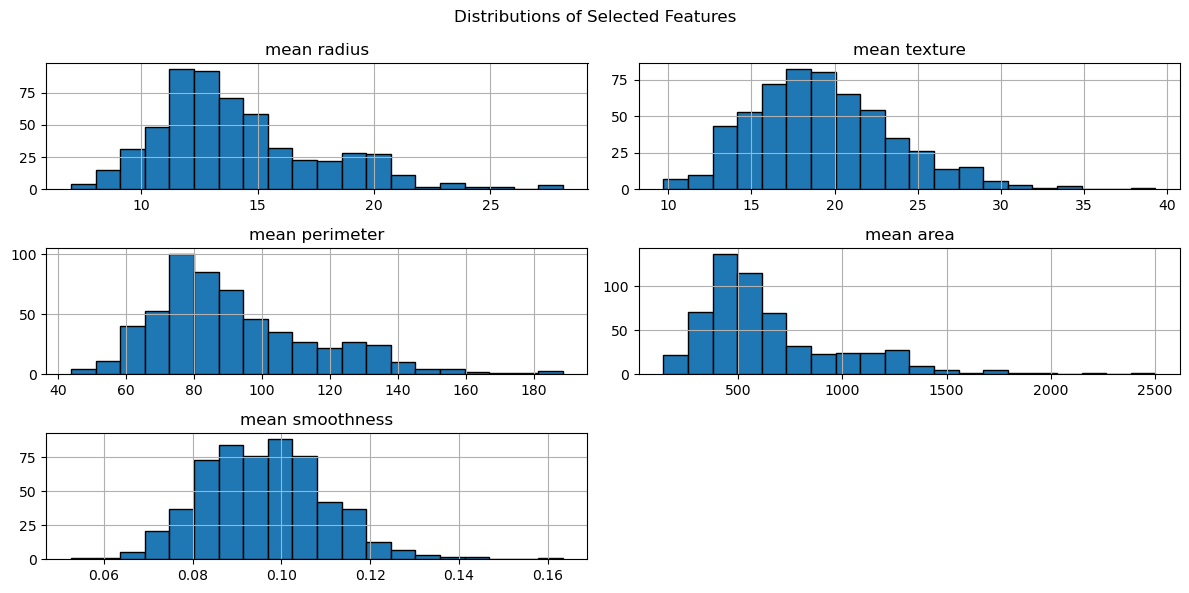

In [8]:
#Creating sample histogram of first five features.
features = ["mean radius", "mean texture", "mean perimeter", "mean area", "mean smoothness"]

#Creating the plots.
df[features].hist(
    bins=20,
    figsize=(12,6),
    edgecolor="black"
)

plt.suptitle("Distributions of Selected Features")
plt.tight_layout()
plt.show()

In [9]:
#Test/Train split for standardization.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

#Initialize the Standard Scaler.
scaler = StandardScaler()

#Fit the training and test data and transform them.
X_training_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nTotal samples: ", X.shape[0])
print("\nTraining size: ", X_train.shape[0])
print("\nTest size: ", X_test.shape[0])
print("\nNumber of features: ", X.shape[1])


Total samples:  569

Training size:  455

Test size:  114

Number of features:  30


In [10]:
#Defining the models to train with Logistic Regression and k-NN.
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    "k-NN (k=3)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=3))
    ]),
    "k-NN (k=5)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    "k-NN (k=7)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=7))
    ])
}

#To train and evaluate each model.
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    #Get classification metrics as a dictionary
    metrics = classification_report(y_test, y_pred, output_dict=True)
    
    results.append({
        "Model": name,
        "Accuracy": metrics["accuracy"],
        "Precision": metrics["weighted avg"]["precision"],
        "Recall": metrics["weighted avg"]["recall"]
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall
0  Logistic Regression  0.982456   0.982456  0.982456
1           k-NN (k=3)  0.982456   0.982930  0.982456
2           k-NN (k=5)  0.956140   0.956073  0.956140
3           k-NN (k=7)  0.973684   0.974737  0.973684


In [11]:
#Sorting models by accuracy to tell which one did better overall.
results_df.sort_values(by=["Accuracy", "Precision"], ascending=False)

,Model,Accuracy,Precision,Recall
1,k-NN (k=3),0.982456,0.982930,0.982456
0,Logistic Regression,0.982456,0.982456,0.982456
3,k-NN (k=7),0.973684,0.974737,0.973684
2,k-NN (k=5),0.956140,0.956073,0.956140


In [12]:
#For cross-validation.
cv_results = [] 

for name, model in models.items():
    accuracy_scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    precision_scores = cross_val_score(model, X, y, cv=5, scoring="precision")
    recall_scores = cross_val_score(model, X, y, cv=5, scoring="recall")

    #Store the results for each fold.
    for fold in range(5):
        cv_results.append({
            "Model": name,
            "Fold": fold+1,
            "Accuracy": accuracy_scores[fold],
            "Precision": precision_scores[fold],
            "Recall": recall_scores[fold]
        })

#Convert results to data frame.
cv_results = pd.DataFrame(cv_results)
print(cv_results)

                  Model  Fold  Accuracy  Precision    Recall
0   Logistic Regression     1  0.982456   0.985915  0.985915
1   Logistic Regression     2  0.982456   0.972603  1.000000
2   Logistic Regression     3  0.973684   0.960000  1.000000
3   Logistic Regression     4  0.973684   0.972603  0.986111
4   Logistic Regression     5  0.991150   1.000000  0.985915
5            k-NN (k=3)     1  0.973684   0.972222  0.985915
6            k-NN (k=3)     2  0.964912   0.958904  0.985915
7            k-NN (k=3)     3  0.982456   0.972973  1.000000
8            k-NN (k=3)     4  0.947368   0.923077  1.000000
9            k-NN (k=3)     5  0.929204   0.943662  0.943662
10           k-NN (k=5)     1  0.964912   0.971831  0.971831
11           k-NN (k=5)     2  0.956140   0.945946  0.985915
12           k-NN (k=5)     3  0.982456   0.972973  1.000000
13           k-NN (k=5)     4  0.956140   0.935065  1.000000
14           k-NN (k=5)     5  0.964602   0.985507  0.957746
15           k-NN (k=7) 

In [13]:
#To calculate the average standard deviation across the 5 folds.
cv_std = cv_results.groupby("Model")[["Accuracy", "Precision", "Recall"]].agg(["mean", "std"])
cv_std.columns = [f"{metric}_{stat}" for metric, stat in cv_std.columns]
cv_std = cv_std.reset_index()
print(cv_std)

                 Model  Accuracy_mean  Accuracy_std  Precision_mean  \
0  Logistic Regression       0.980686      0.007311        0.978224   
1           k-NN (k=3)       0.959525      0.021345        0.954168   
2           k-NN (k=5)       0.964850      0.010744        0.962264   
3           k-NN (k=7)       0.970129      0.009982        0.964845   

   Precision_std  Recall_mean  Recall_std  
0       0.015237     0.991588    0.007679  
1       0.021089     0.983099    0.023143  
2       0.020932     0.983099    0.018364  
3       0.017454     0.988732    0.011784  


In [14]:
#Cross validation for k only.
k_values = list(range(1, 31))
cv_scores = []

for k in k_values:
    pipe_k = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    #Cross validating training data.
    scores = cross_val_score(pipe_k, X_train, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

best_k = k_values[int(np.argmax(cv_scores))]

print("\nBest k by CV on training set: ", best_k)
print("\nBest mean CV accuracy: ", max(cv_scores))


Best k by CV on training set:  7

Best mean CV accuracy:  0.9714285714285715


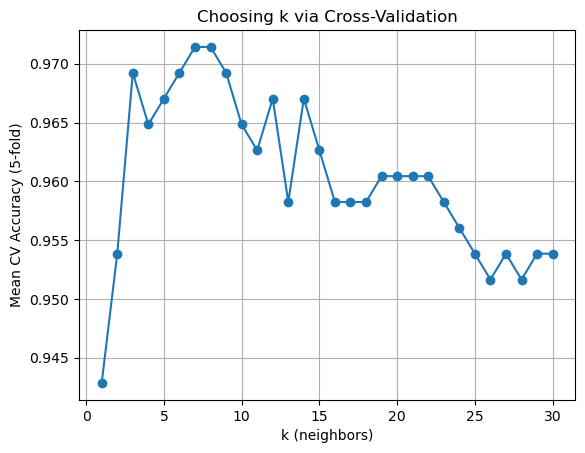

In [15]:
#Make the plots for training k CV.
plt.figure()
plt.plot(k_values, cv_scores, marker="o")
plt.xlabel("k (neighbors)")
plt.ylabel("Mean CV Accuracy (5-fold)")
plt.title("Choosing k via Cross-Validation")
plt.grid(True)
plt.show()

In [16]:
#Fit with best k and evaluate on test data.
best_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=k))
])

best_knn.fit(X_train, y_train)
test_predictions = best_knn.predict(X_test)

print("Test-set classification report:")
print(classification_report(y_test, test_predictions, target_names=cancer.target_names))

Test-set classification report:
              precision    recall  f1-score   support

   malignant       0.97      0.88      0.93        42
      benign       0.93      0.99      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



In [17]:
#To cross validate Logistic Regression.
logistic_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=1000))
])

logistic_scores = cross_val_score(logistic_pipe, X_train, y_train, cv=5, scoring="accuracy")

print("Logistic Regression CV scores: ", logistic_scores)
print("Logistic Regression mean CV accuracy: ", logistic_scores.mean())

Logistic Regression CV scores:  [0.96703297 0.97802198 0.96703297 1.         0.98901099]
Logistic Regression mean CV accuracy:  0.9802197802197803


In [18]:
#To compare Logistic Regression and k-NN in data frame.
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", f"k-NN ({best_k})"],
    "Mean CV Accuracy": [logistic_scores.mean(), max(cv_scores).std()],
    "CV Accuracy Std": [logistic_scores.std(), np.array(cv_scores).std()]
})

print(comparison)
                           

                 Model  Mean CV Accuracy  CV Accuracy Std
0  Logistic Regression           0.98022         0.012815
1             k-NN (7)           0.00000         0.006774


In [19]:
#To fit logistic regression model
logistic_pipe.fit(X_train, y_train)

#To get probablities
logistic_probabilities = logistic_pipe.predict_proba(X_test)[:,1]
knn_probabilities = best_knn.predict_proba(X_test)[:,1]

#Calculate ROC curves
logistic_fpr, logistic_tpr, _ = roc_curve(y_test, logistic_probabilities)
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_probabilities)

#Calculate AUC
logistic_auc = roc_auc_score(y_test, logistic_probabilities)
knn_auc = roc_auc_score(y_test, knn_probabilities)


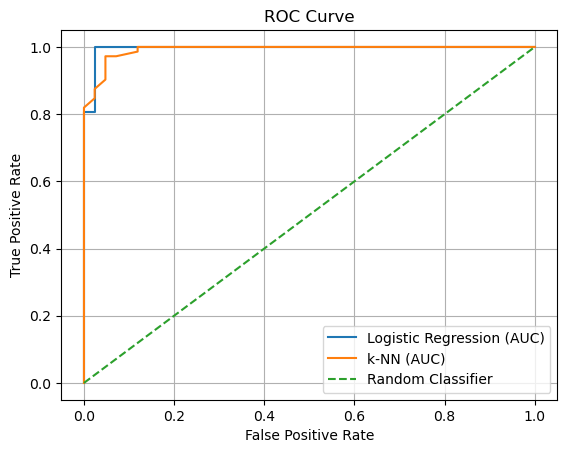

In [20]:
#Plot ROC curves.
plt.figure()
plt.plot(logistic_fpr, logistic_tpr, label="Logistic Regression (AUC)")
plt.plot(knn_fpr, knn_tpr, label="k-NN (AUC)")
plt.plot([0,1], [0,1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
###To stimulate imbalanced data by downsampling one class.
#Combine features and target into one data frame.
imbalanced_df = pd.DataFrame(X, columns=cancer.feature_names)
imbalanced_df["target"] = y

#To separate the two classes.
class0 = imbalanced_df[imbalanced_df["target"]==0]
class1 = imbalanced_df[imbalanced_df["target"]==1]

#To downsample class 1.
class1_downsample = class1.sample(n=len(class1) // 2, random_state=42)

#To recombine the classes.
imbalanced_df = pd.concat([class0, class1_downsample], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

#Seperate features and target again.
X_imbalanced = imbalanced_df.drop(columns="target").values
y_imbalanced = imbalanced_df['target'].values

#To inspect the new class distribution.
print(pd.Series(y_imbalanced).value_counts())
print(pd.Series(y_imbalanced).value_counts(normalize=True))

0    212
1    178
Name: count, dtype: int64
0    0.54359
1    0.45641
Name: proportion, dtype: float64


In [25]:
#Split and evaluate the models on the imbalanced data.
X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(X_imbalanced, y_imbalanced, test_size=0.20, random_state=42, stratify=y_imbalanced)
imbalanced_results = []

for name, model in {"Logistic Regression": logistic_pipe, f"k-NN (k={best_k})": best_knn}.items():
    model.fit(X_train_imb, y_train_imb)
    predictions = model.predict(X_test_imb)
    report = classification_report(y_test_imb, predictions, output_dict=True)
    imbalanced_results.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"]
    })

imbalanced_results_df = pd.DataFrame(imbalanced_results)
print(imbalanced_results_df)

                 Model  Accuracy  Precision    Recall
0  Logistic Regression  0.948718   0.949712  0.948718
1           k-NN (k=7)  0.910256   0.910350  0.910256


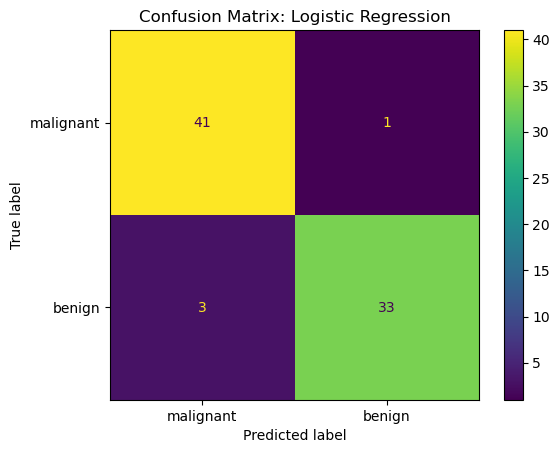

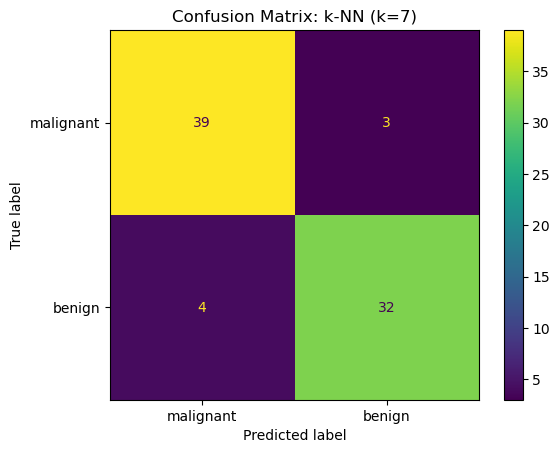

In [26]:
#To inspect the confusion matrixes.
for name, model in {"Logistic Regression": logistic_pipe, f"k-NN (k={best_k})": best_knn}.items():
    predictions = model.predict(X_test_imb)
    confMatrix = confusion_matrix(y_test_imb, predictions)
    display = ConfusionMatrixDisplay(confusion_matrix=confMatrix, display_labels=cancer.target_names)
    display.plot()
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

In [30]:
###To tune hyperparameters further for Logistic Regression.
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
logistic_tuning_results = []

for C in C_values:
    logistic_model = Pipeline([("scaler", StandardScaler()), ("logistic", LogisticRegression(C=C, max_iter=1000))])
    accuracy_scores = cross_val_score(logistic_model, X_train, y_train, cv=5, scoring="accuracy")
    logistic_tuning_results.append({
        "C": C,
        "Mean Accuracy": accuracy_scores.mean(),
        "Std Accuracy": accuracy_scores.std()
    })

logistic_tuning_df = pd.DataFrame(logistic_tuning_results)
print(logistic_tuning_df)

#To print the best regularization value.
best_C = logistic_tuning_df.loc[logistic_tuning_df["Mean Accuracy"].idxmax(), "C"]
print("\nBest regularization value: ", best_C)

         C  Mean Accuracy  Std Accuracy
0    0.001       0.879121      0.025059
1    0.010       0.951648      0.020382
2    0.100       0.980220      0.016150
3    1.000       0.980220      0.012815
4   10.000       0.969231      0.016150
5  100.000       0.956044      0.019658

Best regularization value:  0.1


In [31]:
###To tune hyperparameters further for k-NN.
distance_metrics = ["euclidean", "manhattan", "minkowski"]
knn_tuning_results = []

for metric in distance_metrics:
    knn_model = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=best_k, metric=metric))])
    accuracy_scores = cross_val_score(knn_model, X_train, y_train, cv=5, scoring="accuracy")
    knn_tuning_results.append({
        "Distance Metric": metric,
        "Mean Accuracy": accuracy_scores.mean(),
        "Std Accuracy": accuracy_scores.std()
    })

knn_tuning_df = pd.DataFrame(knn_tuning_results)
print(knn_tuning_df)

#To print the best metric.
best_metric = knn_tuning_df.loc[knn_tuning_df["Mean Accuracy"].idxmax(), "Distance Metric"]
print("\nBest metric value: ", best_metric)
        

  Distance Metric  Mean Accuracy  Std Accuracy
0       euclidean       0.971429      0.019160
1       manhattan       0.967033      0.025059
2       minkowski       0.971429      0.019160

Best metric value:  euclidean
